In [1]:
import pandas as pd
import numpy as np
from os import listdir
from collections import OrderedDict

Average frequency of top-100 tags from vacancies for each keyword-query.

In [2]:
mypath = 'tags/'
mean_val = {}

for d in listdir(mypath):
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'res_php': 0.13268970853908718,
 'EPAM': 0.13053621750038644,
 'микросервис': 0.12710714187707955,
 'res_Java': 0.1110812696742908,
 'res_Javascript': 0.10054028047185669,
 'Intern': 0.08847926091051227,
 'Spark': 0.07985245845323495,
 'DevOps': 0.0778190807655968,
 'res_Data scientist': 0.07777028130306775,
 'res_Python': 0.0770897474977555,
 'Typescript': 0.06547654244006877,
 'php': 0.062067309721335645,
 'Golang': 0.061380950813073064,
 'Frontend': 0.05876558241170876,
 'Javascript': 0.05706022331288655,
 'Data': 0.05492092454765415,
 'C%23': 0.049512330766207195,
 'Java': 0.04590024000967538,
 'SQL': 0.0431515753153023,
 'Data scientist': 0.042145938420922305,
 'C%2B%2B': 0.04159246398313139,
 'Python': 0.03945464851750064}

Average frequency of top-5 tags from vacancies for each keyword-query.

In [3]:
for d in listdir(mypath):
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].iloc[:5].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'res_php': 0.8023845459495609,
 'микросервис': 0.7255969611888,
 'res_Java': 0.5916026858932735,
 'res_Javascript': 0.5801256101731803,
 'Spark': 0.5702623186037323,
 'EPAM': 0.5381886997314914,
 'DevOps': 0.5096702958108338,
 'res_Python': 0.5083134564875282,
 'php': 0.47277750459250273,
 'Typescript': 0.4700006325694612,
 'Frontend': 0.4456612546833247,
 'Golang': 0.4182995205425746,
 'Intern': 0.4107174641487358,
 'Java': 0.3966584405442002,
 'res_Data scientist': 0.38644743968488426,
 'Javascript': 0.3725365953065297,
 'Python': 0.3628112016003776,
 'C%2B%2B': 0.3621823916065063,
 'Data': 0.347547835911001,
 'C%23': 0.34136854228462243,
 'Data scientist': 0.276921118465491,
 'SQL': 0.2548945308100534}

Average frequency of top-100 tags from vacancies for each keyword-query in last date.

In [4]:
mypath = 'tags/'
ordered_dict = OrderedDict()

for d in listdir(mypath):
    avg = []
    avg.append(pd.read_csv(mypath + d + '/' + listdir(mypath + d)[-1])['1.0'].mean())
    ordered_dict[d] = np.array(avg).mean()
    
ordered_dict = dict(sorted(ordered_dict.items(), key=lambda item: item[1], reverse=True))
# ordered_dict

Extracting date from names of files.

In [5]:
import re


date_x = ['9']
for name_file in listdir(mypath + '/Python'):
    date_x.append(re.findall('[0-9]{4}-[0-9]{2}-[0-9]{2}', name_file)[0])

Average frequency of top-100 tags from vacancies for each keyword-query and date, sorted by last date.

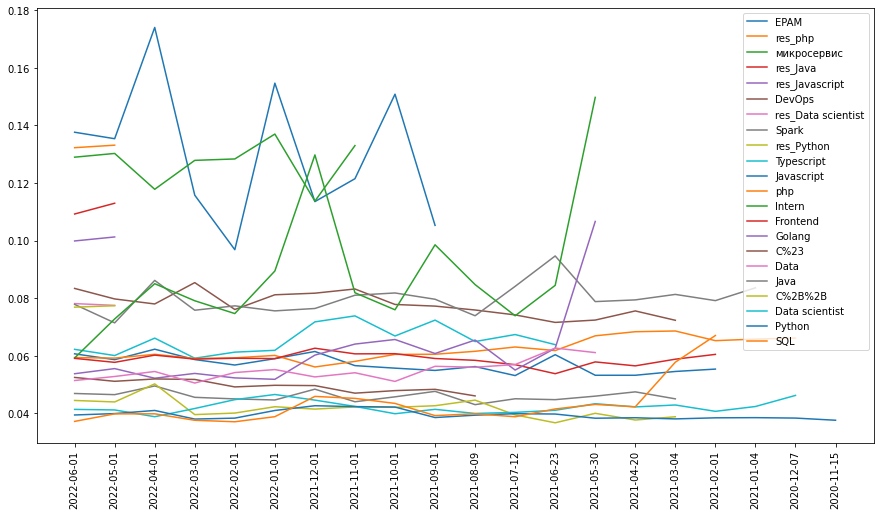

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


all_val = ordered_dict
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

for d in listdir(mypath):
    val = []
    for f in listdir(mypath + d):
        val.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    all_val[d] = val[::-1]
    
all_val.keys()
[ax.plot(all_val[i]) for i in all_val.keys()]
ax.legend([i for i in all_val.keys()])
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xticklabels(sorted(date_x, reverse=True), rotation=90)
plt.show()

In [7]:
# fig, ax = plt.subplots()
# fig.set_size_inches(15, 15)

# keywords = ordered_dict

# for i in listdir(mypath):
#     keywords[i] = pd.read_csv(mypath + i + '/' + listdir(mypath + i)[-1])['1.0']
#     ax.plot(keywords[i])

# ax.legend([i for i in keywords.keys()])